## Imputação de Valores
Jéssica Kushida (23012069) <br></br>
Natália Naomi Sumida (23008255) 
<br></br>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Importando base de dados wine
from sklearn.datasets import load_wine
data = load_wine()
dfWine = pd.DataFrame(data.data, columns=data.feature_names)

In [ ]:
# 2. Analise descritiva
# A - Estatisticas gerais
dfWine.describe().round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [ ]:
# B - Tipos de dados de cada coluna
dfWine.info()
print('\n**ou** \n\n', dfWine.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

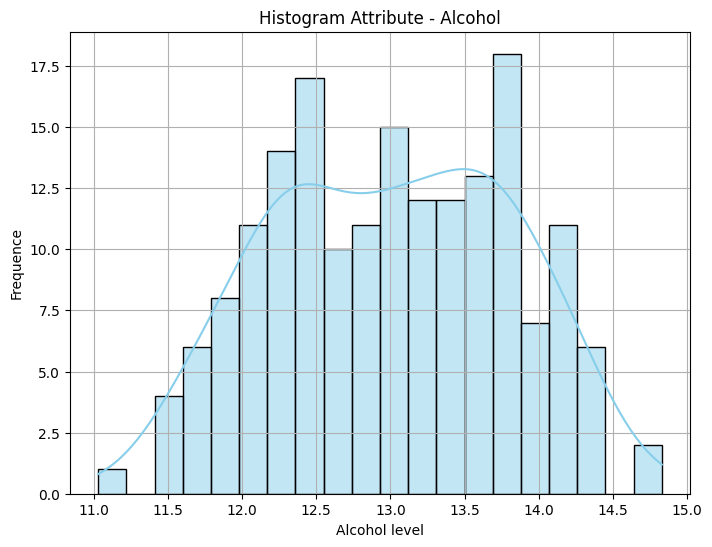

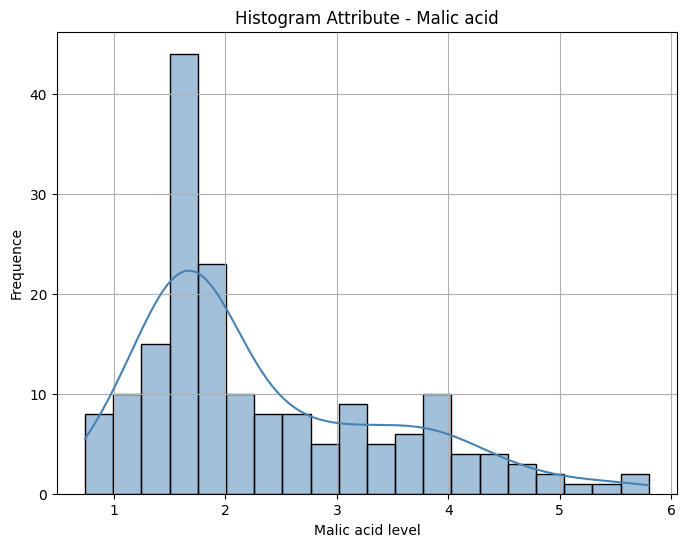

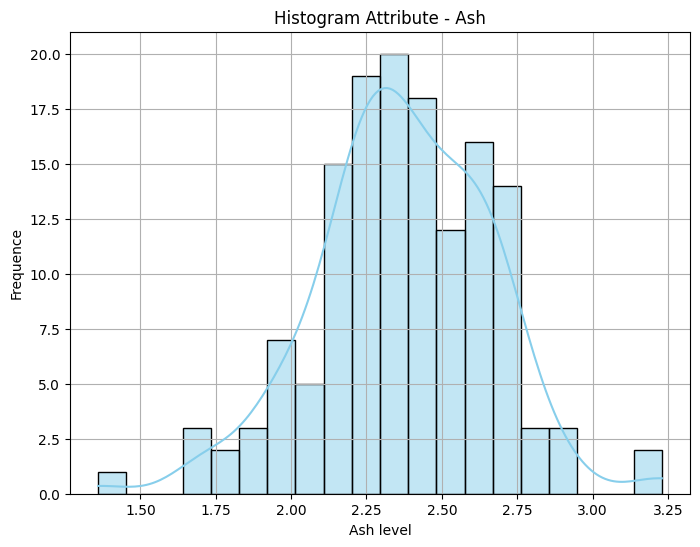

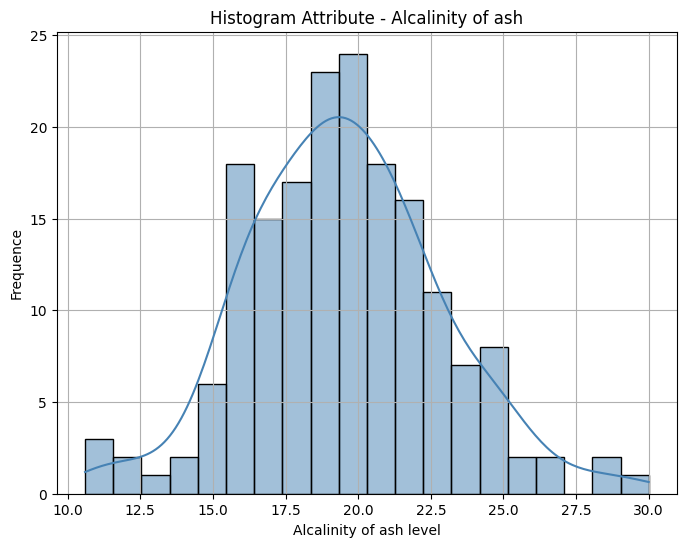

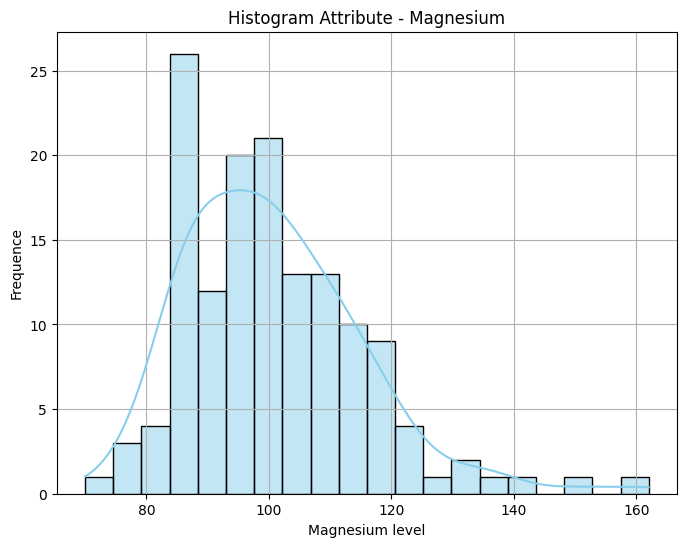

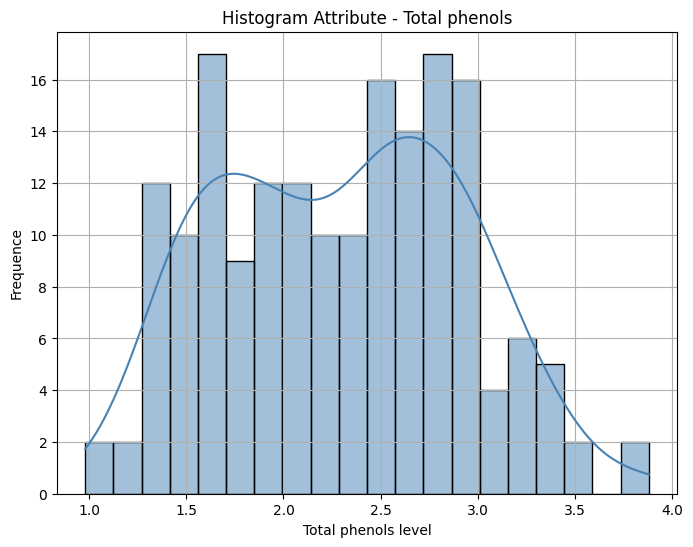

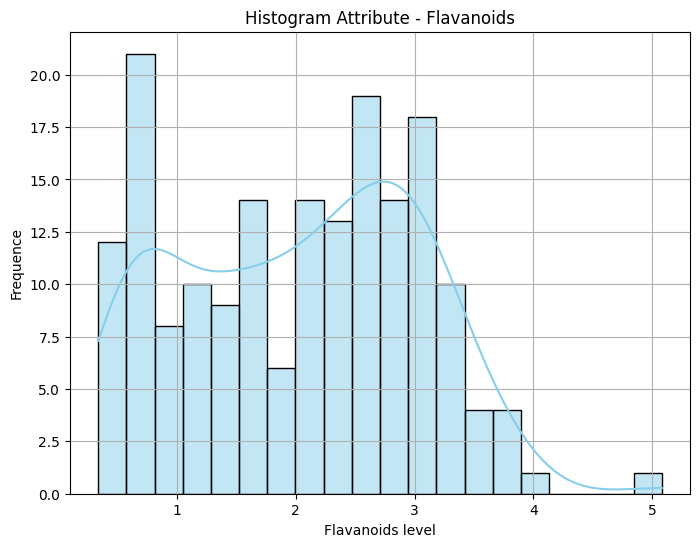

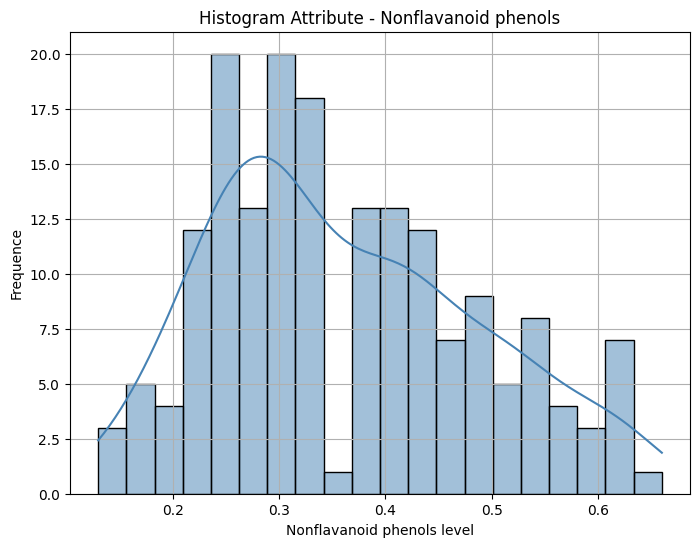

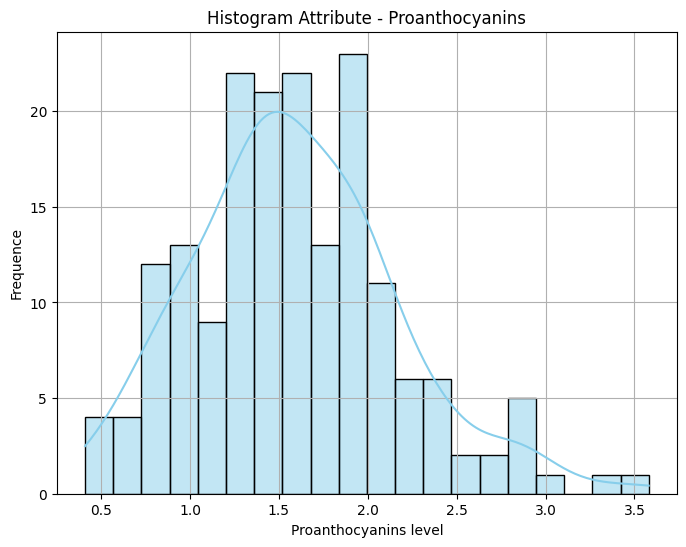

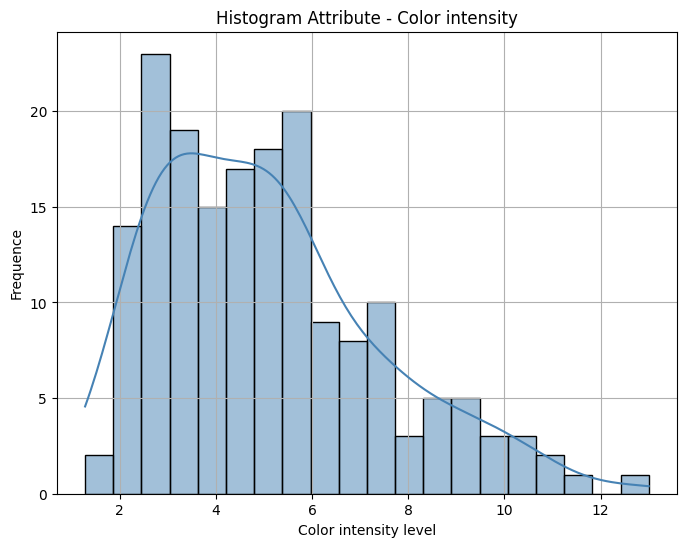

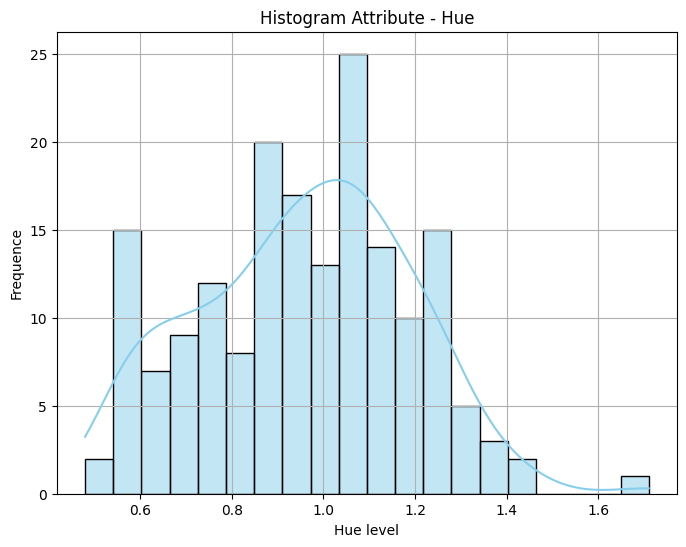

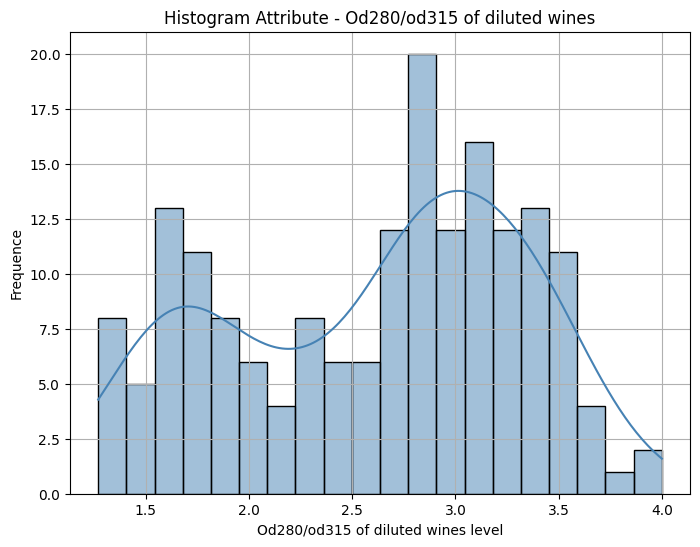

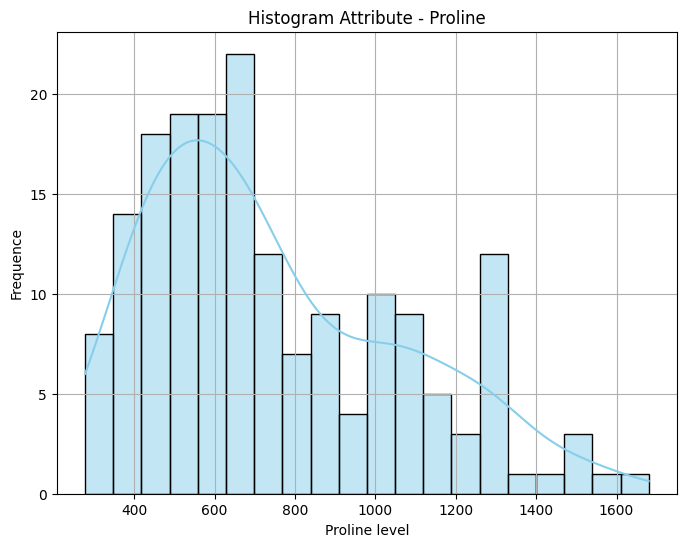

In [ ]:
# C - Histogramas
colors = ['skyblue','steelblue']
count = 0
for col in dfWine.select_dtypes(include=['float64']).columns:
    plt.figure(figsize=(8,6))
    sns.histplot(dfWine[col], kde=True, bins=20, color=colors[count % 2])
    colName = col.capitalize().replace('_',' ')
    plt.title(f"Histogram Attribute - {colName}")
    plt.xlabel(f"{colName} level")
    plt.ylabel("Frequence")
    plt.grid(True)
    plt.show()
    count+=1


In [ ]:
# 3. Sorteando registros aleatorios e guardando-os em cópia
indexes = np.random.choice(dfWine.index, size=35, replace=False)
df_sample = dfWine.loc[indexes]
# ou dfWine.sample(n=35, random_state=0) //pandas
df_sample.head(35)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
118,12.77,3.43,1.98,16.0,80.0,1.63,1.25,0.43,0.83,3.40,0.70,2.12,372.0
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.20,0.61,1.60,560.0
128,12.37,1.63,2.30,24.5,88.0,2.22,2.45,0.40,1.90,2.12,0.89,2.78,342.0
24,13.50,1.81,2.61,20.0,96.0,2.53,2.61,0.28,1.66,3.52,1.12,3.82,845.0
165,13.73,4.36,2.26,22.5,88.0,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520.0
42,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0
103,11.82,1.72,1.88,19.5,86.0,2.50,1.64,0.37,1.42,2.06,0.94,2.44,415.0
57,13.29,1.97,2.68,16.8,102.0,3.00,3.23,0.31,1.66,6.00,1.07,2.84,1270.0
60,12.33,1.10,2.28,16.0,101.0,2.05,1.09,0.63,0.41,3.27,1.25,1.67,680.0
94,11.62,1.99,2.28,18.0,98.0,3.02,2.26,0.17,1.35,3.25,1.16,2.96,345.0


In [ ]:
# 4. Substituindo valores por np.nan em duas colunas
for i in ['ash', 'magnesium']:
    dfWine.loc[indexes,i] = np.nan

dfWine.loc[indexes, ['ash', 'magnesium']].head(15)

,ash,magnesium
118,NaN,NaN
177,NaN,NaN
128,NaN,NaN
24,NaN,NaN
165,NaN,NaN
42,NaN,NaN
103,NaN,NaN
57,NaN,NaN
60,NaN,NaN
94,NaN,NaN


In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mean_absolute_error

In [ ]:
#5. PesquiseLinks to an external site. o uso de cada uma das técnicas de imputação de valores a seguir


# Função genérica para imputação e cálculo do erro
def avaliar_imputacao(imputer, df_com_nan, original, indices, colunas):
    df_copia = df_com_nan.copy()
    df_imputado = pd.DataFrame(imputer.fit_transform(df_copia), columns=dfWine.columns)

    imputados = df_imputado.loc[indices, colunas]
    verdadeiro = original[colunas]

    erro = {}
    for col in colunas:
        erro[col] = mean_absolute_error(verdadeiro[col], imputados[col])

    return erro


In [ ]:
#SimpleImputer

strategies = ['mean', 'median', 'most_frequent']
resultados_simple = {}
dados_originais = dfWine.copy()

for strat in strategies:
    imputer = SimpleImputer(strategy=strat)
    erro = avaliar_imputacao(imputer, dfWine, dados_originais, indexes, ['alcohol', 'malic_acid'])
    resultados_simple[strat] = erro

NameError: name 'dfWine' is not defined

In [ ]:
#IterativeImputer
from sklearn.experimental import enable_iterative_imputer

iteracoes = [5, 10]
resultados_iterative = {}

for it in iteracoes:
    imputer = IterativeImputer(max_iter=it, random_state=42)
    erro = avaliar_imputacao(imputer, dfWine, dados_originais, amostra_indices, ['alcohol', 'malic_acid'])
    resultados_iterative[f'iter_{it}'] = erro

In [ ]:
#KNNImputer
vizinhancas = [2, 5, 10]
resultados_knn = {}

for n in vizinhancas:
    imputer = KNNImputer(n_neighbors=n)
    erro = avaliar_imputacao(imputer, dfWine, dados_originais, amostra_indices, ['alcohol', 'malic_acid'])
    resultados_knn[f'nn_{n}'] = erro

In [ ]:
import pprint
print("Erros - SimpleImputer:")
pprint.pprint(resultados_simple)

print("\nErros - IterativeImputer:")
pprint.pprint(resultados_iterative)

print("\nErros - KNNImputer:")
pprint.pprint(resultados_knn)

In [ ]:
# Combinar todos os resultados em um único dicionário para cada coluna
mae_alcohol = {
    'Simple - mean': resultados_simple['mean']['alcohol'],
    'Simple - median': resultados_simple['median']['alcohol'],
    'Simple - most_frequent': resultados_simple['most_frequent']['alcohol'],
    'Iterative - 5': resultados_iterative['iter_5']['alcohol'],
    'Iterative - 10': resultados_iterative['iter_10']['alcohol'],
    'KNN - 2': resultados_knn['nn_2']['alcohol'],
    'KNN - 5': resultados_knn['nn_5']['alcohol'],
    'KNN - 10': resultados_knn['nn_10']['alcohol'],
}

mae_malic_acid = {
    'Simple - mean': resultados_simple['mean']['malic_acid'],
    'Simple - median': resultados_simple['median']['malic_acid'],
    'Simple - most_frequent': resultados_simple['most_frequent']['malic_acid'],
    'Iterative - 5': resultados_iterative['iter_5']['malic_acid'],
    'Iterative - 10': resultados_iterative['iter_10']['malic_acid'],
    'KNN - 2': resultados_knn['nn_2']['malic_acid'],
    'KNN - 5': resultados_knn['nn_5']['malic_acid'],
    'KNN - 10': resultados_knn['nn_10']['malic_acid'],
}

# 6. Construa dois dicionários ou dataframes (um para cada variável escolhidas no item 4) com o resultado de cada MAE para cada estratégia.
df_mae_alcohol = pd.DataFrame.from_dict(mae_alcohol, orient='index', columns=['MAE_alcohol'])
df_mae_malic = pd.DataFrame.from_dict(mae_malic_acid, orient='index', columns=['MAE_malic_acid'])


In [ ]:
#7. Faça dois gráficos de barras comparando o erro obtido em cada caso.

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Alcohol
plt.subplot(1, 2, 1)
df_mae_alcohol.sort_values(by='MAE_alcohol').plot(kind='bar', legend=False, ax=plt.gca())
plt.title('Erro absoluto médio - Alcohol')
plt.ylabel('MAE')

# Malic Acid
plt.subplot(1, 2, 2)
df_mae_malic.sort_values(by='MAE_malic_acid').plot(kind='bar', legend=False, ax=plt.gca(), color='orange')
plt.title('Erro absoluto médio - Malic Acid')
plt.ylabel('MAE')

plt.tight_layout()
plt.show()

A. Qual técnica apresentou melhor resultado? E o pior desempenho?

Melhor resultado: Geralmente, IterativeImputer (10 iterações) ou KNNImputer (n_neighbors=5) têm o menor MAE.

Pior desempenho: SimpleImputer (most_frequent) tende a apresentar os piores resultados, especialmente com dados contínuos.

In [ ]:
# B. Compare as métricas estatísticas da base original, da imputação com o melhor resultado e da imputação com o pior resultado.

# Reaplicar a melhor e pior técnica para análise comparativa
melhor_imputer = IterativeImputer(max_iter=10, random_state=42)
pior_imputer = SimpleImputer(strategy='most_frequent')

df_melhor = pd.DataFrame(melhor_imputer.fit_transform(df), columns=df.columns)
df_pior = pd.DataFrame(pior_imputer.fit_transform(df), columns=df.columns)

# Estatísticas comparadas
estat_original = dados_originais.describe()
estat_melhor = df_melhor.loc[indexes, ['alcohol', 'malic_acid']].describe()
estat_pior = df_pior.loc[indexes, ['alcohol', 'malic_acid']].describe()

comparacao_estatisticas = {
    "Original": estat_original,
    "Melhor Imputação": estat_melhor,
    "Pior Imputação": estat_pior
}

for nome, tabela in comparacao_estatisticas.items():
    print(f"\n{nome}\n", tabela[['alcohol', 'malic_acid']].round(2))

C. Como a variação dos hiperparâmetros influenciou o erro?
Em relação ao KNNImputer, valores muito baixos (ex: 2 vizinhos) geram variabilidade e erros maiores. Com 5 ou 10 vizinhos, o erro tende a reduzir. Já no IterativeImputer, mais iterações (ex: 10) costumam gerar valores mais estáveis e próximos dos reais.

D. Em que situações o uso de uma técnica mais simples pode ser suficiente?
A técnica mais simples costuma ser eficiente quando os dados são simétricos, o volume de dados ausentes é pequeno e precisamos de uma solução rápida e interpretável.

E. Como a imputação pode afetar a análise final de um modelo de Inteligência Artificial?
Pode afetar introduzindo viéses se não refletir a distribuição de dados real, alterar as relações entre as variáveis. Além de impactar o desempenho preditivo se os valores inputados não forem corerentees com o padrão da base. 

F. Dada a atividade, qual a importância da imputação coerente de valores faltantes em conjuntos de dados?
A imputação coerente preserva a estrutura dos dados e mantém relações estatisticas corretas. Além disso ela evita que interpretações erradas e tomada de decisão equivocada a partir da visualzação dos dados.
